## HỆ THỐNG DỰ ĐOÁN KHÁCH HÀNG RỜI ĐI 

# Kiến thức cần biết

- **CSV File**: Tệp chứa dữ liệu dạng bảng, giống như Excel
- **Pandas**: Thư viện Python để làm việc với dữ liệu
- **Features (Đặc trưng)**: Các cột dữ liệu về khách hàng (tuổi, dịch vụ, ...)
- **X (Input)**: Các thông tin về khách hàng → **ĐẦU VÀO**
- **y (Target/Output)**: Kết quả khách hàng có rời đi hay không → **ĐẦU RA**

In [3]:
##Import thư viện cần thiết
# pandas - thư viện để làm việc với dữ liệu 
# numpy - thư viện tính toán
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt  # vẽ đồ thị
import seaborn as sns  # vẽ đồ thị pro
import warnings
warnings.filterwarnings('ignore')

# Cấu hình matplotlib để hiển thị tiếng Việt
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
sns.set_style("whitegrid")

In [4]:
# Đọc file CSV vào Python

df = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')
print(f"Số dòng (khách hàng): {df.shape[0]:,}")
print(f"Số cột (đặc trưng): {df.shape[1]}")
print(f"\nKích thước: {df.shape}")

Số dòng (khách hàng): 7,043
Số cột (đặc trưng): 21

Kích thước: (7043, 21)


In [5]:
print(df.head())

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

## Ý nghĩa từng cột dữ liệu

| Cột | Ý nghĩa | Loại |
|-----|---------|------|
| **customerID** | Mã khách hàng | ID  |
| **gender** | Giới tính (Male/Female) | Chữ |
| **SeniorCitizen** | Là người cao tuổi (0/1) | Số (0=không, 1=có) |
| **Partner** | Có bạn đời (Yes/No) | Chữ |
| **Dependents** | Có người phụ thuộc (Yes/No) | Chữ |
| **tenure** | Số tháng làm khách hàng | Số |
| **PhoneService** | Có dùng điện thoại (Yes/No) | Chữ |
| **InternetService** | Loại internet (DSL/Fiber/No) | Chữ |
| **OnlineSecurity** | Bảo mật online (Yes/No/No internet) | Chữ |
| **Contract** | Loại hợp đồng (Month-to-month/One year/Two year) | Chữ |
| **MonthlyCharges** | Tiền hàng tháng | Số |
| **TotalCharges** | Tổng tiền từng trả | Số |
| **Churn** | **RỜI ĐI** (Yes/No) → **CẦN DỰ ĐOÁN CỘT NÀY** | Chữ  |

### Cách phân loại dữ liệu:
- **Input (X)**: Tất cả các cột TRỪ "Churn" (để dự đoán)
- **Output (y)**: Cột "Churn" (mục tiêu cần dự đoán)

In [6]:
# Kiểm tra kiểu dữ liệu và thông tin chi tiết
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## Kiểm tra dữ liệu thiếu (Missing Values)

In [7]:
# Kiểm tra dữ liệu thiếu
missing_data = df.isnull().sum()  # Đếm số giá trị NaN (thiếu) trong từng cột
print(missing_data[missing_data > 0])  # Chỉ in các cột có dữ liệu thiếu


Series([], dtype: int64)


## Phân bố Churn 

Khách hàng ở lại (No):   5174 ( 73.5%)
Khách hàng rời đi (Yes):  1869 ( 26.5%)


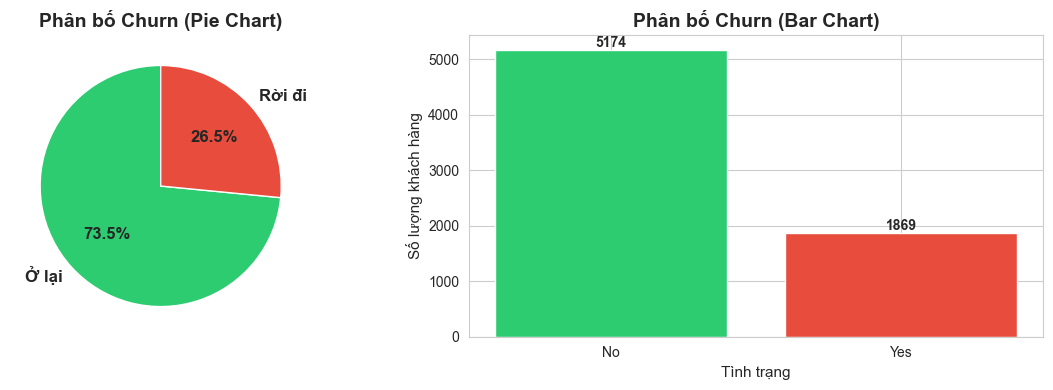

In [8]:
churn_counts = df['Churn'].value_counts()
churn_percent = df['Churn'].value_counts(normalize=True) * 100

print(f"Khách hàng ở lại (No):  {churn_counts['No']:>5} ({churn_percent['No']:>5.1f}%)")
print(f"Khách hàng rời đi (Yes): {churn_counts['Yes']:>5} ({churn_percent['Yes']:>5.1f}%)")

# Vẽ biểu đồ
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Biểu đồ tròn (Pie Chart)
axes[0].pie(churn_counts.values, 
            labels=['Ở lại', 'Rời đi'],
            autopct='%1.1f%%',
            colors=['#2ecc71', '#e74c3c'],
            startangle=90,
            textprops={'fontsize': 12, 'weight': 'bold'})
axes[0].set_title('Phân bố Churn (Pie Chart)', fontsize=14, weight='bold')

# Biểu đồ cột (Bar Chart)
axes[1].bar(churn_counts.index, churn_counts.values, color=['#2ecc71', '#e74c3c'])
axes[1].set_ylabel('Số lượng khách hàng', fontsize=11)
axes[1].set_xlabel('Tình trạng', fontsize=11)
axes[1].set_title('Phân bố Churn (Bar Chart)', fontsize=14, weight='bold')
for i, v in enumerate(churn_counts.values):
    axes[1].text(i, v + 50, str(v), ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

## So sánh Churn theo từng đặc trưng

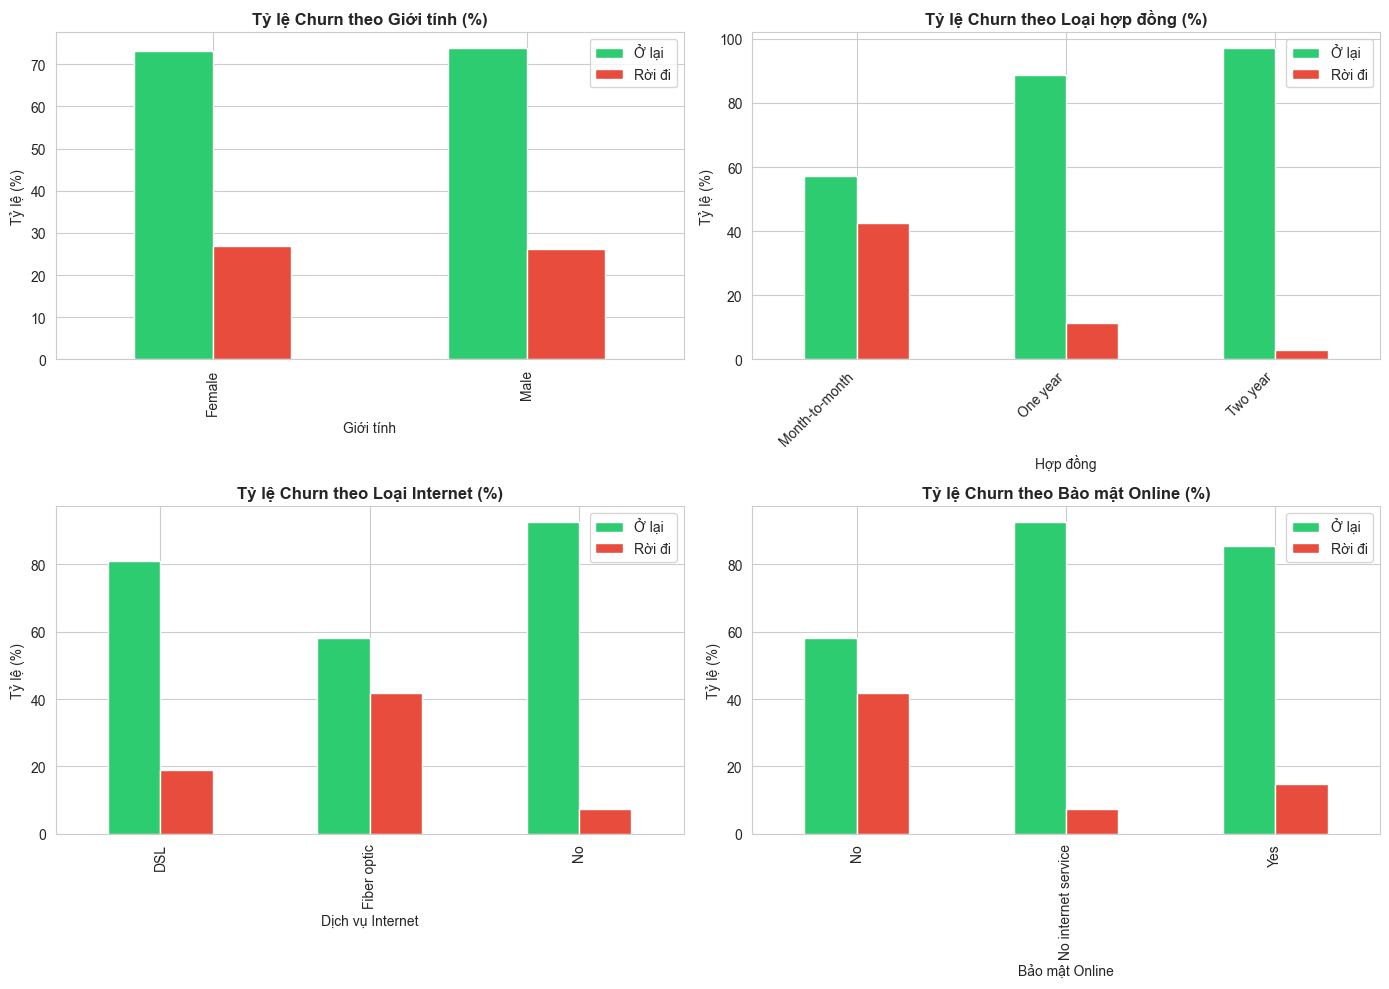

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Churn theo giới tính
gender_churn = pd.crosstab(df['gender'], df['Churn'], normalize='index') * 100
gender_churn.plot(kind='bar', ax=axes[0, 0], color=['#2ecc71', '#e74c3c'])
axes[0, 0].set_title('Tỷ lệ Churn theo Giới tính (%)', fontsize=12, weight='bold')
axes[0, 0].set_xlabel('Giới tính')
axes[0, 0].set_ylabel('Tỷ lệ (%)')
axes[0, 0].legend(['Ở lại', 'Rời đi'])

# 2. Churn theo loại hợp đồng 
contract_churn = pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100
contract_churn.plot(kind='bar', ax=axes[0, 1], color=['#2ecc71', '#e74c3c'])
axes[0, 1].set_title('Tỷ lệ Churn theo Loại hợp đồng (%)', fontsize=12, weight='bold')
axes[0, 1].set_xlabel('Hợp đồng')
axes[0, 1].set_ylabel('Tỷ lệ (%)')
axes[0, 1].legend(['Ở lại', 'Rời đi'])
plt.setp(axes[0, 1].xaxis.get_majorticklabels(), rotation=45, ha='right')

# 3. Churn theo Internet Service
internet_churn = pd.crosstab(df['InternetService'], df['Churn'], normalize='index') * 100
internet_churn.plot(kind='bar', ax=axes[1, 0], color=['#2ecc71', '#e74c3c'])
axes[1, 0].set_title('Tỷ lệ Churn theo Loại Internet (%)', fontsize=12, weight='bold')
axes[1, 0].set_xlabel('Dịch vụ Internet')
axes[1, 0].set_ylabel('Tỷ lệ (%)')
axes[1, 0].legend(['Ở lại', 'Rời đi'])

# 4. Churn theo Bảo mật Online
security_churn = pd.crosstab(df['OnlineSecurity'], df['Churn'], normalize='index') * 100
security_churn.plot(kind='bar', ax=axes[1, 1], color=['#2ecc71', '#e74c3c'])
axes[1, 1].set_title('Tỷ lệ Churn theo Bảo mật Online (%)', fontsize=12, weight='bold')
axes[1, 1].set_xlabel('Bảo mật Online')
axes[1, 1].set_ylabel('Tỷ lệ (%)')
axes[1, 1].legend(['Ở lại', 'Rời đi'])

plt.tight_layout()
plt.show()

# Từ biểu đồ, ta thấy:
* Hợp đồng tháng: Tỷ lệ churn rất cao (42%)
* Hợp đồng 2 năm: Tỷ lệ churn rất thấp (3%)
* Internet Fiber: Tỷ lệ churn cao hơn DSL
* Không có bảo mật: Tỷ lệ churn cao

# TIỀN XỬ LÝ DỮ LIỆU

## Fix lỗi dữ liệu

In [10]:
print(df.info())
df.head(10)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
5,9305-CDSKC,Female,0,No,No,8,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes
6,1452-KIOVK,Male,0,No,Yes,22,Yes,Yes,Fiber optic,No,...,No,No,Yes,No,Month-to-month,Yes,Credit card (automatic),89.10,1949.4,No
7,6713-OKOMC,Female,0,No,No,10,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,No,Mailed check,29.75,301.9,No
8,7892-POOKP,Female,0,Yes,No,28,Yes,Yes,Fiber optic,No,...,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes
9,6388-TABGU,Male,0,No,Yes,62,Yes,No,DSL,Yes,...,No,No,No,No,One year,No,Bank transfer (automatic),56.15,3487.95,No


Cột TotalCharges bị lưu dưới dạng chữ thay vì số -> cần chuyển đồi
Vì dữ liệu bị thiếu chỉ có 11 dòng khá bé so với tổng dữ liệu nên ta xóa đi

In [11]:
# Chuyển đổi TotalCharges sang kiểu số
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')# errors='coerce' sẽ chuyển các giá trị không thể chuyển đổi thành NaN mà không báo lỗi
# Lưu ý nếu dùng hàm astype sẽ báo lỗi khi gặp giá trị không thể chuyển đổi, còn errors='coerce' sẽ giúp chúng ta xử lý dữ liệu một cách linh hoạt hơn mà không bị gián đoạn bởi lỗi.

# Xóa các dòng có giá trị thiếu trong TotalCharges 
df = df.dropna(subset=['TotalCharges'])

In [12]:
# Xóa cột không cần thiết
df = df.drop(columns=['customerID'])

##  Xử lý dữ liệu trung lặp


In [13]:
df.duplicated().sum() # Kiểm tra dữ liệu trùng lặp

np.int64(22)

In [14]:
df[df.duplicated()] # Hiển thị các dòng trùng lặp nếu có

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
964,Male,0,No,No,1,Yes,No,DSL,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,45.70,45.70,Yes
1338,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.15,20.15,Yes
1491,Female,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,19.55,19.55,No
1739,Male,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.90,69.90,Yes
1932,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.20,20.20,No
2713,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Mailed check,20.45,20.45,No
2892,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.45,20.45,No
3301,Female,1,No,No,1,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,69.60,69.60,Yes
3754,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,20.05,20.05,No
4098,Male,0,No,No,1,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,Yes,Mailed check,20.20,20.20,Yes


In [15]:
df_cleaned = df.drop_duplicates()
df_cleaned.shape

(7010, 20)

##  Xử lý dữ liệu sai và outlier


In [16]:
df_cleaned.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7010.000000,7010.000000,7010.000000,7010.000000
mean,0.162767,32.520399,64.888666,2290.353388
std,0.369180,24.520441,30.064769,2266.820832
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.750000,408.312500
50%,0.000000,29.000000,70.400000,1403.875000
75%,0.000000,56.000000,89.900000,3807.837500
max,1.000000,72.000000,118.750000,8684.800000


Không thấy giá trị nào khả nghi 

## Mã hóa dữ liệu (ENCODING)

In [17]:
categorical_cols = df.select_dtypes(include=['object']).columns.tolist() # Lấy danh sách các cột có kiểu dữ liệu là object (chữ)
print(f"Các cột kiểu chữ cần mã hóa: {categorical_cols}")

# Sử dụng pd.get_dummies để mã hóa
# drop_first=True: Xóa cột thừa để tránh multicollinearity(tương quan đa chiều- khi có nhiều cột mã hóa từ cùng 1 cột gốc sẽ có mối quan hệ tuyến tính giữa các cột mã hóa)
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True, dtype=int)
df_encoded.head()

Các cột kiểu chữ cần mã hóa: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']


,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,...,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check,Churn_Yes
0,0,1,29.85,29.85,0,1,0,0,1,0,...,0,0,0,0,0,1,0,1,0,0
1,0,34,56.95,1889.50,1,0,0,1,0,0,...,0,0,0,1,0,0,0,0,1,0
2,0,2,53.85,108.15,1,0,0,1,0,0,...,0,0,0,0,0,1,0,0,1,1
3,0,45,42.30,1840.75,1,0,0,0,1,0,...,0,0,0,1,0,0,0,0,0,0
4,0,2,70.70,151.65,0,0,0,1,0,0,...,0,0,0,0,0,1,0,1,0,1


In [18]:
# Tách X (Input) và y (Output)
X = df_encoded.drop('Churn_Yes', axis=1)  # 'Churn_Yes' là output
y = df_encoded['Churn_Yes']  # y = Output cần dự đoán

In [19]:
# Tách dữ liệu Train / Test
from sklearn.model_selection import train_test_split

# train_test_split: Chia dữ liệu thành 2 phần
# test_size=0.2: 20% dùng để test, 80% dùng để train
# random_state=42: Để kết quả lặp lại được
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y  # Đảm bảo tỷ lệ churn không đổi trong train/test
)


In [20]:
# Chuẩn hóa dữ liệu
from sklearn.preprocessing import StandardScaler 
scaler = StandardScaler()  

# Xác định cột số cần scaling
numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges'] # Vì 3 cột này có thang đo khác nhau, nên cần chuẩn hóa để mô hình không bị ưu tiên cột có giá trị lớn hơn

# Fit trên train, transform trên train
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])

# Transform trên test 
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])



#  XÂY DỰNG MÔ HÌNH - LOGISTIC REGRESSION
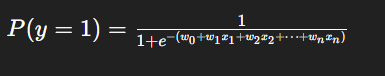


In [21]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000) # max_iter=1000 để đảm bảo mô hình có đủ thời gian hội tụ, tránh lỗi không hội tụ khi dữ liệu phức tạp hoặc có nhiều đặc trưng
lr_model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul


# ĐÁNH GIÁ MÔ HÌNH 
### **Accuracy (Độ chính xác)** - Phần trăm dự đoán đúng
### **Precision (Độ chính xác cao)** - Trong những người ta dự đoán "rời đi", bao nhiêu thực sự rời?
- **Công thức**: Đúng Dương / (Đúng Dương + Sai Dương)


### **Recall (Độ bao phủ)** - Trong tất cả những người thực sự rời, ta bắt được bao nhiêu?
- **Công thức**: Đúng Dương / (Đúng Dương + Sai Âm)
### **F1-Score** - Cân bằng giữa Precision và Recall
- **Công thức**: 2 × (Precision × Recall) / (Precision + Recall)

In [22]:
# Dự đoán trên test set
y_pred_lr = lr_model.predict(X_test)
y_pred_proba = lr_model.predict_proba(X_test)[:, 1]  # Xác suất rời đi
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

# Tính toán metric
accuracy = accuracy_score(y_test, y_pred_lr)
precision = precision_score(y_test, y_pred_lr)
recall = recall_score(y_test, y_pred_lr)
f1 = f1_score(y_test, y_pred_lr)
print(f"   Accuracy:  {accuracy:.4f} ({accuracy*100:.1f}%)")
print(f"   Precision: {precision:.4f} ({precision*100:.1f}%)")
print(f"   Recall:    {recall:.4f} ({recall*100:.1f}%)")
print(f"   F1-Score:  {f1:.4f}")

   Accuracy:  0.8045 (80.5%)
   Precision: 0.6505 (65.0%)
   Recall:    0.5722 (57.2%)
   F1-Score:  0.6088


#### GIẢI THÍCH:
   * Dự đoán đúng: 80.5% trường hợp
   * Trong những người ta bảo sẽ rời: 65.0% thực sự rời
   * Trong những người thực sự rời: ta bắt được 57.2%
### -> Đây là bài toán mà ta nên ưu tiên tìm ra số người rời đi để ta có thể cứu vãn được nhưng với Recall chỉ 57.2%, mô hình đang bỏ sót quá nhiều khách hàng quan trọng. Ta đang để mất gần một nửa số khách hàng cần cứu vãn

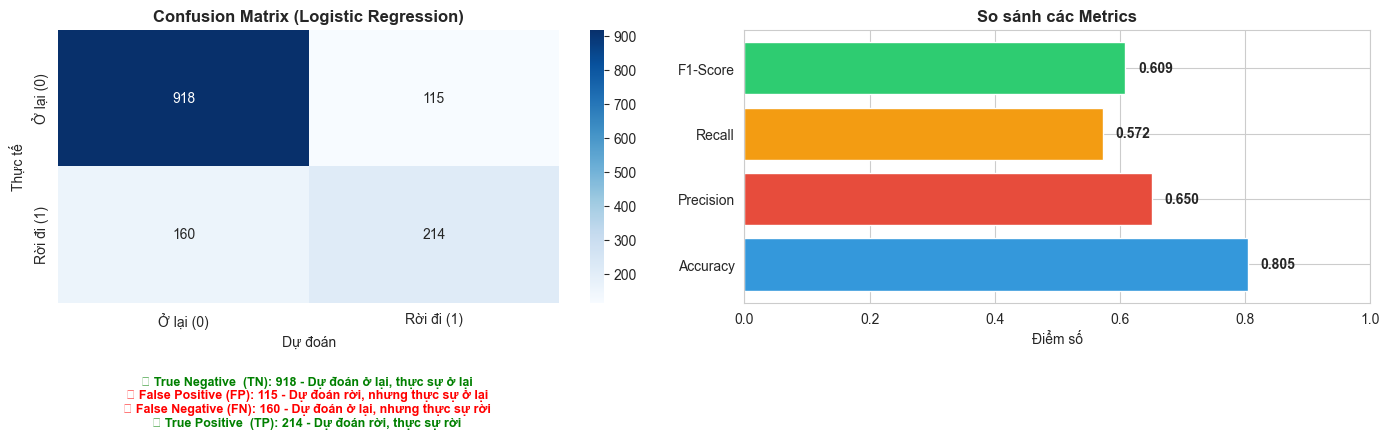

In [30]:
# Vẽ Confusion Matrix
cm = confusion_matrix(y_test, y_pred_lr)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0], 
            xticklabels=['Ở lại (0)', 'Rời đi (1)'],
            yticklabels=['Ở lại (0)', 'Rời đi (1)'])
axes[0].set_title('Confusion Matrix (Logistic Regression)', fontsize=12, weight='bold')
axes[0].set_ylabel('Thực tế')
axes[0].set_xlabel('Dự đoán')

# Giải thích
tn, fp, fn, tp = cm.ravel()
axes[0].text(0.5, -0.3, f'✓ True Negative  (TN): {tn} - Dự đoán ở lại, thực sự ở lại ',
            ha='center', transform=axes[0].transAxes, fontsize=9, color='green', weight='bold')
axes[0].text(0.5, -0.35, f'✗ False Positive (FP): {fp} - Dự đoán rời, nhưng thực sự ở lại ',
            ha='center', transform=axes[0].transAxes, fontsize=9, color='red', weight='bold')
axes[0].text(0.5, -0.40, f'✗ False Negative (FN): {fn} - Dự đoán ở lại, nhưng thực sự rời ',
            ha='center', transform=axes[0].transAxes, fontsize=9, color='red', weight='bold')
axes[0].text(0.5, -0.45, f'✓ True Positive  (TP): {tp} - Dự đoán rời, thực sự rời ',
            ha='center', transform=axes[0].transAxes, fontsize=9, color='green', weight='bold')

# Biểu đồ các metric
metrics_names = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
metrics_values = [accuracy, precision, recall, f1]
colors = ['#3498db', '#e74c3c', '#f39c12', '#2ecc71']

axes[1].barh(metrics_names, metrics_values, color=colors)
axes[1].set_xlabel('Điểm số')
axes[1].set_title('So sánh các Metrics', fontsize=12, weight='bold')
axes[1].set_xlim(0, 1)

for i, v in enumerate(metrics_values):
    axes[1].text(v + 0.02, i, f'{v:.3f}', va='center', weight='bold')

plt.tight_layout()
plt.show()


# CẢI THIỆN MÔ HÌNH - SO SÁNH NHIỀU MÔ HÌNH

In [24]:

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


dt_model = DecisionTreeClassifier(random_state=42, max_depth=10)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)


rf_model = RandomForestClassifier(n_estimators=100, random_state=42, max_depth=10)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)


In [25]:
# So sánh tất cả các mô hình
# Tính toán metric cho mỗi mô hình
models_names = ['Logistic Regression', 'Decision Tree', 'Random Forest']
y_preds = [y_pred_lr, y_pred_dt, y_pred_rf]

results = []
for name, y_pred in zip(models_names, y_preds):
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1_val = f1_score(y_test, y_pred)
    results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1_val
    })

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

# Tìm mô hình tốt nhất
best_model_idx = results_df['F1-Score'].idxmax()
best_model_name = results_df.loc[best_model_idx, 'Model']


              Model  Accuracy  Precision   Recall  F1-Score
Logistic Regression  0.804549   0.650456 0.572193  0.608819
      Decision Tree  0.752665   0.543333 0.435829  0.483680
      Random Forest  0.790334   0.632107 0.505348  0.561664


## 10-fold Cross Validation (k=10) + gridSearch với dữ liệu mẫu nhỏ để tối ưu Recall

Ta sẽ lấy **một tập nhỏ** từ dữ liệu huấn luyện để thử tinh chỉnh hyperparameter, giảm thời gian chạy nhưng vẫn đưa ra tham số tốt.

Sau khi tìm được tham số, ta sẽ đánh giá lại trên tập test đầy đủ.


## Logistic Regression với k=10

In [26]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Lấy 20% dữ liệu train để tuning nhanh hơn
X_small, _, y_small, _ = train_test_split(X_train, y_train, test_size=0.8, random_state=42, stratify=y_train)

kf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)


param_grid_lr = {
    'C': [0.01, 0.1, 1, 10],
    'class_weight': [None, 'balanced'],
    'max_iter': [1000, 2000]
}

lr_base = LogisticRegression(random_state=42)
grid_search_lr = GridSearchCV(
    estimator=lr_base,
    param_grid=param_grid_lr,
    scoring='recall',
    cv=kf,
    n_jobs=-1,
    verbose=1
)

grid_search_lr.fit(X_small, y_small)

# Đánh giá trên test set
best_lr = grid_search_lr.best_estimator_
y_test_pred_lr_tuned = best_lr.predict(X_test)
recall_lr_tuned = recall_score(y_test, y_test_pred_lr_tuned)
precision_lr_tuned = precision_score(y_test, y_test_pred_lr_tuned)
accuracy_lr_tuned = accuracy_score(y_test, y_test_pred_lr_tuned)
f1_lr_tuned = f1_score(y_test, y_test_pred_lr_tuned)

print(f"   Recall:    {recall_lr_tuned:.4f}")
print(f"   Precision: {precision_lr_tuned:.4f}")
print(f"   Accuracy:  {accuracy_lr_tuned:.4f}")
print(f"   F1-Score:  {f1_lr_tuned:.4f}")

Fitting 10 folds for each of 16 candidates, totalling 160 fits
   Recall:    0.7941
   Precision: 0.4934
   Accuracy:  0.7285
   F1-Score:  0.6086



## Tuning Decision Tree với k=10

In [27]:
param_grid_dt = {
    'max_depth': [3, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': [None, 'balanced']
}

dt_base = DecisionTreeClassifier(random_state=42)
grid_search_dt = GridSearchCV(
    estimator=dt_base,
    param_grid=param_grid_dt,
    scoring='recall',
    cv=kf,
    n_jobs=-1,
    verbose=1
)

grid_search_dt.fit(X_small, y_small)


# Đánh giá trên test set
best_dt = grid_search_dt.best_estimator_
y_test_pred_dt_tuned = best_dt.predict(X_test)
recall_dt_tuned = recall_score(y_test, y_test_pred_dt_tuned)
precision_dt_tuned = precision_score(y_test, y_test_pred_dt_tuned)
accuracy_dt_tuned = accuracy_score(y_test, y_test_pred_dt_tuned)
f1_dt_tuned = f1_score(y_test, y_test_pred_dt_tuned)
print(f"   Recall:    {recall_dt_tuned:.4f}")
print(f"   Precision: {precision_dt_tuned:.4f}")
print(f"   Accuracy:  {accuracy_dt_tuned:.4f}")
print(f"   F1-Score:  {f1_dt_tuned:.4f}")

Fitting 10 folds for each of 72 candidates, totalling 720 fits
   Recall:    0.8075
   Precision: 0.4879
   Accuracy:  0.7235
   F1-Score:  0.6083



## Tuning Random Forest với k=10

In [28]:
param_grid_rf = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, 15],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'class_weight': [None, 'balanced']
}

rf_base = RandomForestClassifier(random_state=42)
grid_search_rf = GridSearchCV(
    estimator=rf_base,
    param_grid=param_grid_rf,
    scoring='recall',
    cv=kf,
    n_jobs=-1,
    verbose=1
)

grid_search_rf.fit(X_small, y_small)

# Đánh giá trên test set
best_rf = grid_search_rf.best_estimator_
y_test_pred_rf_tuned = best_rf.predict(X_test)
recall_rf_tuned = recall_score(y_test, y_test_pred_rf_tuned)
precision_rf_tuned = precision_score(y_test, y_test_pred_rf_tuned)
accuracy_rf_tuned = accuracy_score(y_test, y_test_pred_rf_tuned)
f1_rf_tuned = f1_score(y_test, y_test_pred_rf_tuned)

print(f"   Recall:    {recall_rf_tuned:.4f}")
print(f"   Precision: {precision_rf_tuned:.4f}")
print(f"   Accuracy:  {accuracy_rf_tuned:.4f}")
print(f"   F1-Score:  {f1_rf_tuned:.4f}")

Fitting 10 folds for each of 48 candidates, totalling 480 fits
   Recall:    0.7647
   Precision: 0.5098
   Accuracy:  0.7420
   F1-Score:  0.6118



## So sánh tất cả 3 mô hình sau tuning

              Model   Recall  Precision  Accuracy  F1-Score
Logistic Regression 0.794118   0.493355  0.728500  0.608607
      Decision Tree 0.807487   0.487884  0.723525  0.608258
      Random Forest 0.764706   0.509804  0.742004  0.611765

MÔ HÌNH CÓ RECALL CAO NHẤT: Decision Tree (0.8075)


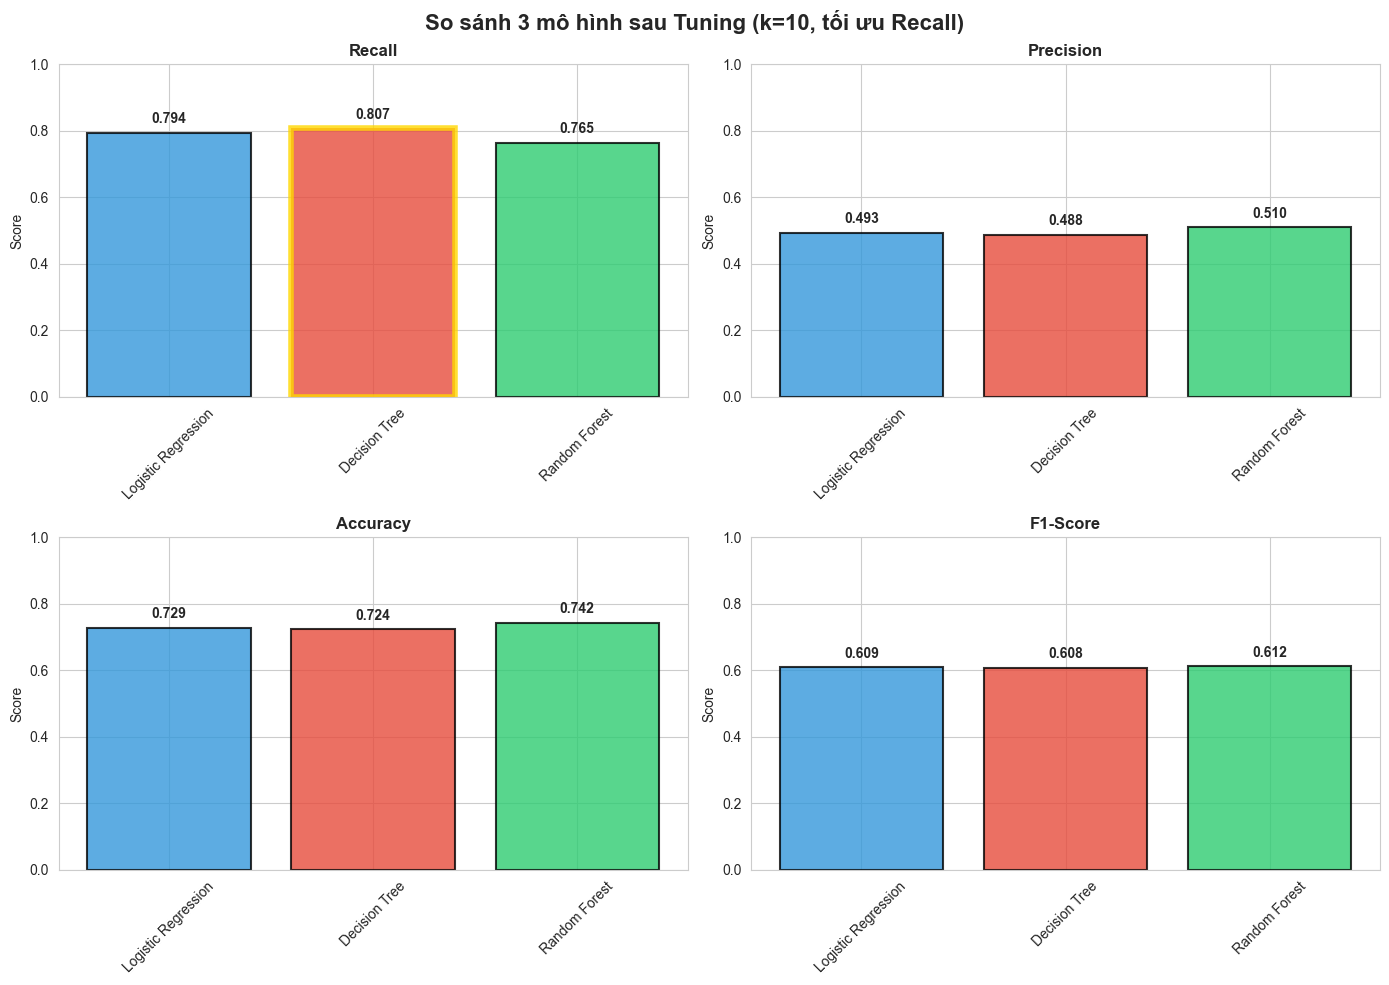

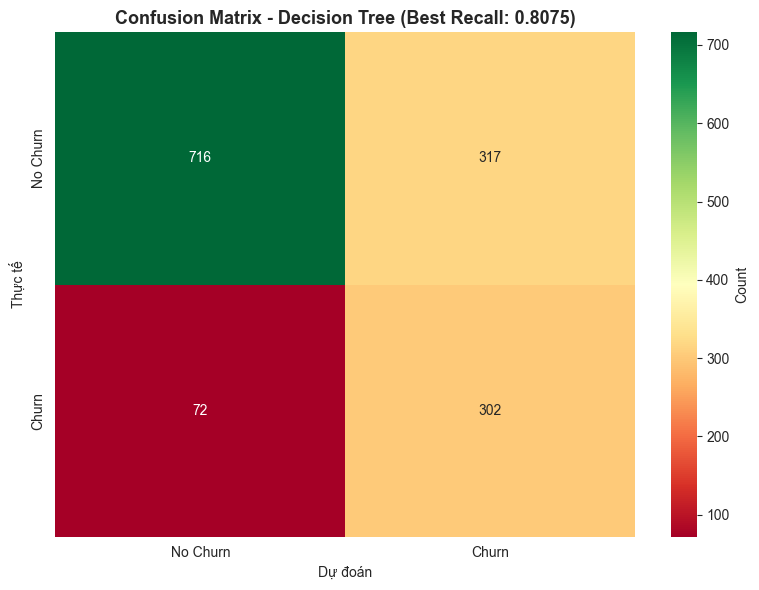

In [29]:
results_tuned = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Recall': [recall_lr_tuned, recall_dt_tuned, recall_rf_tuned],
    'Precision': [precision_lr_tuned, precision_dt_tuned, precision_rf_tuned],
    'Accuracy': [accuracy_lr_tuned, accuracy_dt_tuned, accuracy_rf_tuned],
    'F1-Score': [f1_lr_tuned, f1_dt_tuned, f1_rf_tuned]
})

print(results_tuned.to_string(index=False))

best_recall_idx = results_tuned['Recall'].idxmax()
best_recall_model = results_tuned.loc[best_recall_idx, 'Model']
best_recall_value = results_tuned.loc[best_recall_idx, 'Recall']

print(f"\nMÔ HÌNH CÓ RECALL CAO NHẤT: {best_recall_model} ({best_recall_value:.4f})")

# Vẽ biểu đồ so sánh
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('So sánh 3 mô hình sau Tuning (k=10, tối ưu Recall)', fontsize=16, weight='bold')

metrics = ['Recall', 'Precision', 'Accuracy', 'F1-Score']
colors = ['#3498db', '#e74c3c', '#2ecc71']

for idx, metric in enumerate(metrics):
    row = idx // 2
    col = idx % 2
    
    values = results_tuned[metric].values
    bars = axes[row, col].bar(results_tuned['Model'], values, color=colors, alpha=0.8, edgecolor='black', linewidth=1.5)
    axes[row, col].set_title(f'{metric}', fontsize=12, weight='bold')
    axes[row, col].set_ylabel('Score')
    axes[row, col].set_ylim(0, 1)
    axes[row, col].tick_params(axis='x', rotation=45)
    
    # Viết giá trị trên cột
    for i, (bar, val) in enumerate(zip(bars, values)):
        height = bar.get_height()
        axes[row, col].text(bar.get_x() + bar.get_width()/2., height + 0.02,
                           f'{val:.3f}', ha='center', va='bottom', weight='bold', fontsize=10)
        
        # Highlight tốt nhất cho Recall
        if metric == 'Recall' and i == best_recall_idx:
            bar.set_edgecolor('gold')
            bar.set_linewidth(4)

plt.tight_layout()
plt.show()

# Vẽ Confusion Matrix cho model best recall
if best_recall_idx == 0:
    y_pred_best = y_test_pred_lr_tuned
    cm_best = confusion_matrix(y_test, y_pred_best)
elif best_recall_idx == 1:
    y_pred_best = y_test_pred_dt_tuned
    cm_best = confusion_matrix(y_test, y_pred_best)
else:
    y_pred_best = y_test_pred_rf_tuned
    cm_best = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_best, annot=True, fmt='d', cmap='RdYlGn', 
            xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'],
            cbar_kws={'label': 'Count'})
plt.title(f'Confusion Matrix - {best_recall_model} (Best Recall: {best_recall_value:.4f})', 
         fontsize=13, weight='bold')
plt.xlabel('Dự đoán')
plt.ylabel('Thực tế')
plt.tight_layout()
plt.show()
